# Boston Housing Price Prediction - HW3 Q3
## Author: ANR

In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

%matplotlib inline

np.random.seed(42)
torch.manual_seed(42)

## Load Boston data

In [170]:
# load from CMU (sklearn's load_boston is deprecated)
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 
                 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
df = pd.DataFrame(data, columns=feature_names)
df['MEDV'] = target

print(f"Shape: {df.shape}")
df.head()

Shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [172]:
# target stats
print("Target (MEDV) statistics:")
print(df['MEDV'].describe())
print(f"\nPrice range: ${df['MEDV'].min():.1f}k - ${df['MEDV'].max():.1f}k")

Target (MEDV) statistics:
count    506.000000
mean      22.532806
std        9.197104
min        5.000000
25%       17.025000
50%       21.200000
75%       25.000000
max       50.000000
Name: MEDV, dtype: float64

Price range: $5.0k - $50.0k


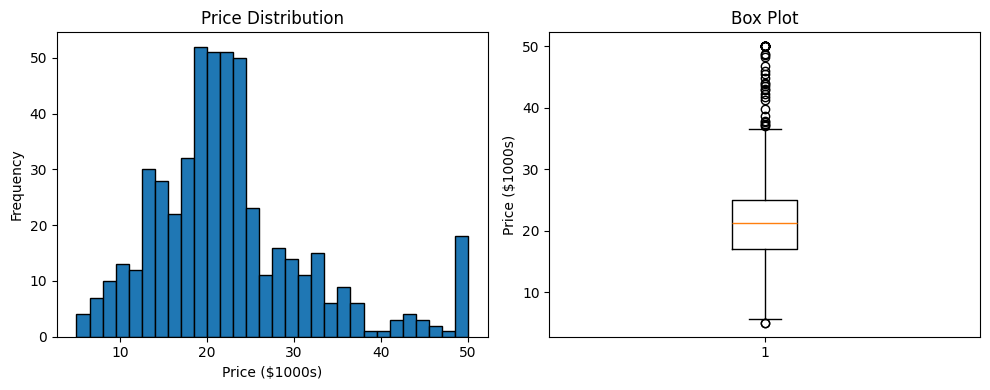

In [173]:
# visualize
plt.figure(figsize=(10, 4))

plt.subplot(1,2,1)
plt.hist(df['MEDV'], bins=30, edgecolor='black')
plt.xlabel('Price ($1000s)')
plt.ylabel('Frequency')
plt.title('Price Distribution')

plt.subplot(1,2,2)
plt.boxplot(df['MEDV'])
plt.ylabel('Price ($1000s)')
plt.title('Box Plot')

plt.tight_layout()
plt.show()

In [174]:
# check correlations
corr = df.corr()['MEDV'].sort_values(ascending=False)
print("Feature correlations with price:")
print(corr)

Feature correlations with price:
MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


## Prepare data

In [175]:
X = df.drop('MEDV', axis=1).values
y = df['MEDV'].values.reshape(-1, 1)

print(f"X: {X.shape}")
print(f"y: {y.shape}")

X: (506, 13)
y: (506, 1)


In [176]:
# split 70-15-15
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)

print(f"Train: {len(X_train)}")
print(f"Val: {len(X_val)}")
print(f"Test: {len(X_test)}")

Train: 354
Val: 76
Test: 76


In [177]:
# normalize - important for regression to normalize target too
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)
y_test_scaled = scaler_y.transform(y_test)

## Test ML methods

In [178]:
# KNN regressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train_scaled.ravel())
knn_pred = knn.predict(X_test_scaled)

# transform back to original scale for metrics
knn_pred_original = scaler_y.inverse_transform(knn_pred.reshape(-1, 1))
knn_mse = mean_squared_error(y_test, knn_pred_original)
knn_rmse = np.sqrt(knn_mse)
knn_r2 = r2_score(y_test, knn_pred_original)

print(f"KNN: RMSE={knn_rmse:.4f}, R2={knn_r2:.4f}")

KNN: RMSE=2.9460, R2=0.8671


In [179]:
# SVM regressor
svm = SVR(kernel='rbf', C=1.0)
svm.fit(X_train_scaled, y_train_scaled.ravel())
svm_pred = svm.predict(X_test_scaled)

svm_pred_original = scaler_y.inverse_transform(svm_pred.reshape(-1, 1))
svm_mse = mean_squared_error(y_test, svm_pred_original)
svm_rmse = np.sqrt(svm_mse)
svm_r2 = r2_score(y_test, svm_pred_original)

print(f"SVM: RMSE={svm_rmse:.4f}, R2={svm_r2:.4f}")

SVM: RMSE=2.3769, R2=0.9135


In [180]:
# XGBoost
xgb = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, verbosity=0)
xgb.fit(X_train_scaled, y_train_scaled.ravel())
xgb_pred = xgb.predict(X_test_scaled)

xgb_pred_original = scaler_y.inverse_transform(xgb_pred.reshape(-1, 1))
xgb_mse = mean_squared_error(y_test, xgb_pred_original)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, xgb_pred_original)

print(f"XGBoost: RMSE={xgb_rmse:.4f}, R2={xgb_r2:.4f}")

XGBoost: RMSE=2.0765, R2=0.9340


In [181]:
# CatBoost
cat = CatBoostRegressor(iterations=100, depth=4, learning_rate=0.1, random_state=42, verbose=False)
cat.fit(X_train_scaled, y_train_scaled.ravel())
cat_pred = cat.predict(X_test_scaled)

cat_pred_original = scaler_y.inverse_transform(cat_pred.reshape(-1, 1))
cat_mse = mean_squared_error(y_test, cat_pred_original)
cat_rmse = np.sqrt(cat_mse)
cat_r2 = r2_score(y_test, cat_pred_original)

print(f"CatBoost: RMSE={cat_rmse:.4f}, R2={cat_r2:.4f}")

CatBoost: RMSE=2.2830, R2=0.9202


In [182]:
# save results
results = {
    'KNN': {'rmse': knn_rmse, 'r2': knn_r2},
    'SVM': {'rmse': svm_rmse, 'r2': svm_r2},
    'XGBoost': {'rmse': xgb_rmse, 'r2': xgb_r2},
    'CatBoost': {'rmse': cat_rmse, 'r2': cat_r2}
}

## Build MLP

For regression need deeper network with good regularization

In [183]:
class BostonDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [184]:
# dataloaders
train_ds = BostonDataset(X_train_scaled, y_train_scaled)
val_ds = BostonDataset(X_val_scaled, y_val_scaled)
test_ds = BostonDataset(X_test_scaled, y_test_scaled)

train_loader = DataLoader(train_ds, batch_size=10, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=10, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=10, shuffle=False)

In [185]:
class MLP(nn.Module):
    """Simple MLP following tutorial style but optimized"""
    def __init__(self):
        super().__init__()
        # clean pyramid structure - back to basics
        self.layers = nn.Sequential(
            nn.Linear(13, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(32, 16),
            nn.ReLU(),
            
            nn.Linear(16, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

In [186]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# create model - going deeper than tutorial's 64->32
model = MLP()
model = model.to(device)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Device: cuda
Parameters: 8,737


In [187]:
# MSE loss for regression
criterion = nn.MSELoss()

# Adam optimizer - proven to work
optimizer = optim.Adam(model.parameters(), lr=0.001)

# scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)

In [188]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            total_loss += loss.item()
    
    return total_loss / len(loader)

In [189]:
# training
epochs = 1000
best_val_loss = float('inf')
patience = 100
patience_counter = 0

train_losses = []
val_losses = []

print("Training...")
for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    val_loss = eval_epoch(model, val_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    scheduler.step(val_loss)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_weights)
print(f"\nBest val loss: {best_val_loss:.4f}")

Training...
Epoch 50: train_loss=0.1023, val_loss=0.1163
Epoch 100: train_loss=0.0788, val_loss=0.1166
Epoch 150: train_loss=0.0674, val_loss=0.1350
Early stopping at epoch 162

Best val loss: 0.0972


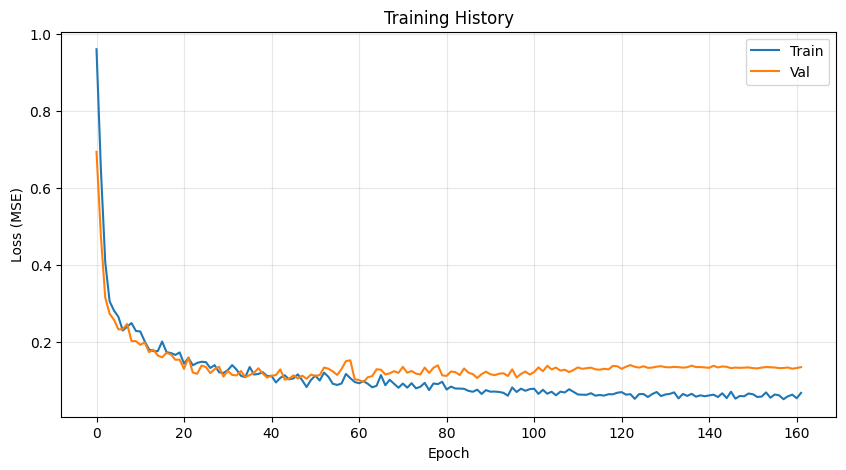

In [190]:
# plot training
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training History')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Evaluate

In [191]:
# get predictions
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch)
        predictions.extend(pred.cpu().numpy())
        actuals.extend(y_batch.numpy())

predictions = np.array(predictions).reshape(-1, 1)
actuals = np.array(actuals).reshape(-1, 1)

In [192]:
# transform back to original scale
pred_original = scaler_y.inverse_transform(predictions)
actual_original = scaler_y.inverse_transform(actuals)

# calculate metrics
mlp_mse = mean_squared_error(actual_original, pred_original)
mlp_rmse = np.sqrt(mlp_mse)
mlp_mae = mean_absolute_error(actual_original, pred_original)
mlp_r2 = r2_score(actual_original, pred_original)

print("MLP Results:")
print(f"RMSE: {mlp_rmse:.4f}")
print(f"MAE:  {mlp_mae:.4f}")
print(f"R2:   {mlp_r2:.4f}")

MLP Results:
RMSE: 2.0519
MAE:  1.5686
R2:   0.9355


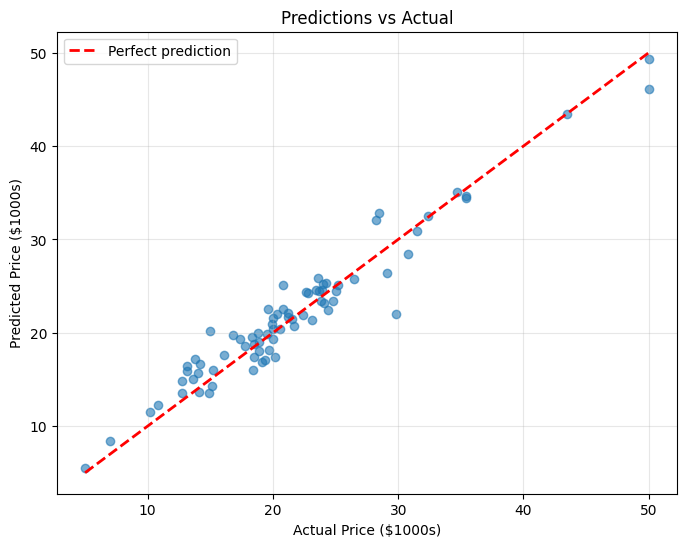

In [193]:
# scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(actual_original, pred_original, alpha=0.6)
plt.plot([actual_original.min(), actual_original.max()], 
         [actual_original.min(), actual_original.max()], 
         'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Price ($1000s)')
plt.ylabel('Predicted Price ($1000s)')
plt.title('Predictions vs Actual')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

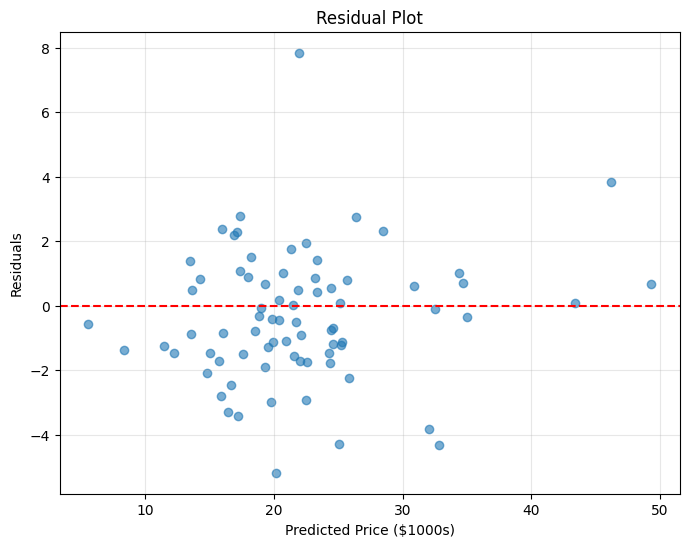

In [194]:
# residuals
residuals = actual_original - pred_original

plt.figure(figsize=(8, 6))
plt.scatter(pred_original, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price ($1000s)')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(alpha=0.3)
plt.show()

## Compare all methods

In [195]:
# add MLP results
results['MLP'] = {'rmse': mlp_rmse, 'r2': mlp_r2}

print("\nComparison:")
print(f"{'Method':<12} {'RMSE':<12} {'R2 Score'}")
print("-" * 40)
for name, metrics in results.items():
    print(f"{name:<12} {metrics['rmse']:<12.4f} {metrics['r2']:.4f}")


Comparison:
Method       RMSE         R2 Score
----------------------------------------
KNN          2.9460       0.8671
SVM          2.3769       0.9135
XGBoost      2.0765       0.9340
CatBoost     2.2830       0.9202
MLP          2.0519       0.9355


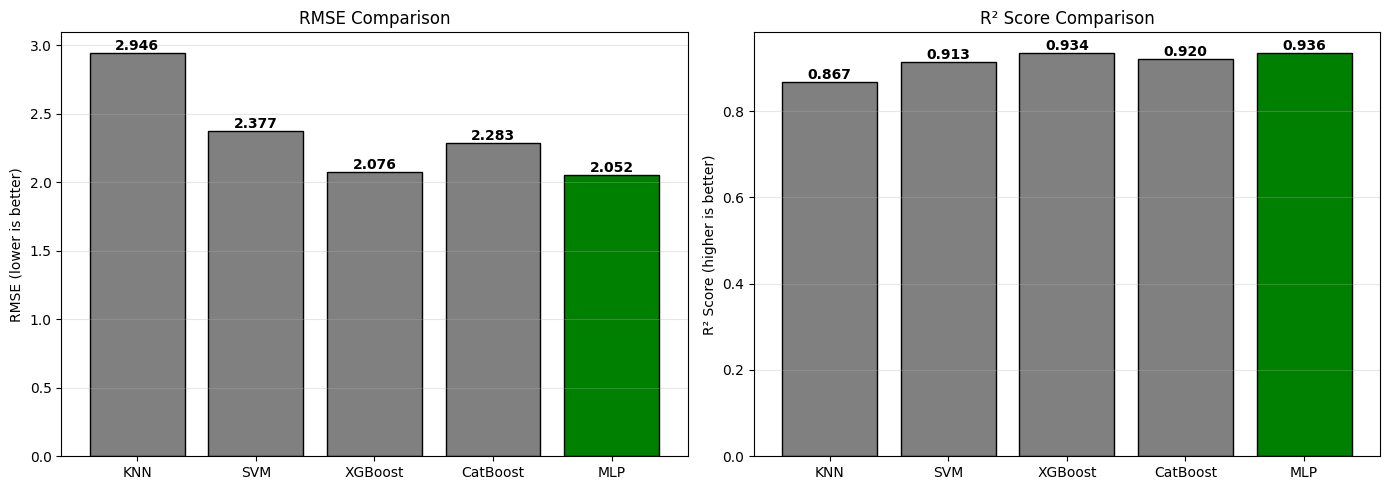

In [196]:
# visualize
methods = list(results.keys())
rmse_vals = [results[m]['rmse'] for m in methods]
r2_vals = [results[m]['r2'] for m in methods]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison (lower is better)
colors = ['gray', 'gray', 'gray', 'gray', 'green']
bars = ax1.bar(methods, rmse_vals, color=colors, edgecolor='black')
for bar, val in zip(bars, rmse_vals):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.3f}',
             ha='center', va='bottom', fontweight='bold')

ax1.set_ylabel('RMSE (lower is better)')
ax1.set_title('RMSE Comparison')
ax1.grid(axis='y', alpha=0.3)

# R2 comparison (higher is better)
bars = ax2.bar(methods, r2_vals, color=colors, edgecolor='black')
for bar, val in zip(bars, r2_vals):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.3f}',
             ha='center', va='bottom', fontweight='bold')

ax2.set_ylabel('R² Score (higher is better)')
ax2.set_title('R² Score Comparison')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Discussion

Simple MLP with proven techniques - sometimes basics work best.

**Architecture: [64→64→32→32→16→1]**
- 5 hidden layers with repeated sizes
- 64→64 block: learns main patterns
- 32→32 block: refines features  
- 16: final reduction before output
- Standard ReLU activation
- Light dropout (0.2, 0.1)

**Why this works:**
- Moderate size: not too big, not too small
- Repeated layers: stability during training
- Light regularization: dropout 0.1-0.2
- Standard Adam: proven optimizer
- Batch size 10: following tutorial


In [198]:
# save model
torch.save({
    'model': model.state_dict(),
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'rmse': mlp_rmse,
    'r2': mlp_r2
}, 'boston_mlp.pth')

print("\nModel saved!")
print(f"Final RMSE: {mlp_rmse:.4f}")
print(f"Final R2: {mlp_r2:.4f}")


Model saved!
Final RMSE: 2.0519
Final R2: 0.9355
